In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import seaborn as sns
from scipy import stats

In [56]:
df_temp = pd.read_csv("..\\Data\\Tmean_obs.csv", parse_dates=True, skiprows = 26, delimiter="\\s+", header=None) 
df_temp.columns = ["date", "Tmean [C]",]
df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y%m%d")

df_temp.set_index("date", inplace=True)

df_prcp = pd.read_csv("..\\Data\\prcp_obs.csv", parse_dates=True, skiprows = 27, delimiter="\\s+", header=None)
df_prcp.columns = ["date", "precip [mm/day]"]
df_prcp["date"] = pd.to_datetime(df_prcp["date"], format="%Y%m%d")

df_prcp.set_index("date", inplace=True)

df_snow = pd.read_csv("..\\Data\\mean_snowcover_timeseries.csv", parse_dates=True, delimiter=",") 
df_snow.columns = ["date", "Snowpack [m]"]
df_snow["date"] = pd.to_datetime(df_snow["date"])
df_snow.set_index("date", inplace=True)
df_snow = df_snow.resample("d").mean()

df_disc = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", parse_dates=True, skiprows = 1, delimiter=";", decimal=",")
df_disc.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
df_disc.dropna(inplace=True)
df_disc.columns = ["date", "Q(m3/s)"]
df_disc.set_index(pd.to_datetime(pd.to_datetime(df_disc["date"]).dt.date), inplace=True)
df_disc.drop(columns=["date"], inplace=True)
df_disc = df_disc.resample("D").mean()

df = df_temp.join(df_prcp).join(df_snow).join(df_disc)
# df.dropna(inplace=True)
display(df)



,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s)
date,,,,
1920-01-01,-11.853330,1.414465,NaN,NaN
1920-01-02,-13.153330,0.208641,NaN,NaN
1920-01-03,-20.386670,0.000000,NaN,NaN
1920-01-04,-8.796666,0.000000,NaN,NaN
1920-01-05,-12.690000,0.000000,NaN,NaN
...,...,...,...,...
2025-10-27,-1.356667,0.000000,0.009877,23.653758
2025-10-28,-4.233333,0.000000,0.011440,22.214355
2025-10-29,-6.763333,0.852455,0.012004,20.837645


In [57]:
df['date'] = df.index

display(df)

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s),date
date,,,,,
1920-01-01,-11.853330,1.414465,NaN,NaN,1920-01-01
1920-01-02,-13.153330,0.208641,NaN,NaN,1920-01-02
1920-01-03,-20.386670,0.000000,NaN,NaN,1920-01-03
1920-01-04,-8.796666,0.000000,NaN,NaN,1920-01-04
1920-01-05,-12.690000,0.000000,NaN,NaN,1920-01-05
...,...,...,...,...,...
2025-10-27,-1.356667,0.000000,0.009877,23.653758,2025-10-27
2025-10-28,-4.233333,0.000000,0.011440,22.214355,2025-10-28
2025-10-29,-6.763333,0.852455,0.012004,20.837645,2025-10-29


In [58]:
### plot parameters ###
w_hist = 12 # width histogram
h_hist = 4  # height histogram

w_time = 15 # width time series
h_time = 3  # height time series

lw = 0.8 # line width
lc = 'black' # line color
ms = 7 # marker size
mc = 'red' # marker color
mt = 'x'
alpha = 0.5 # transparency

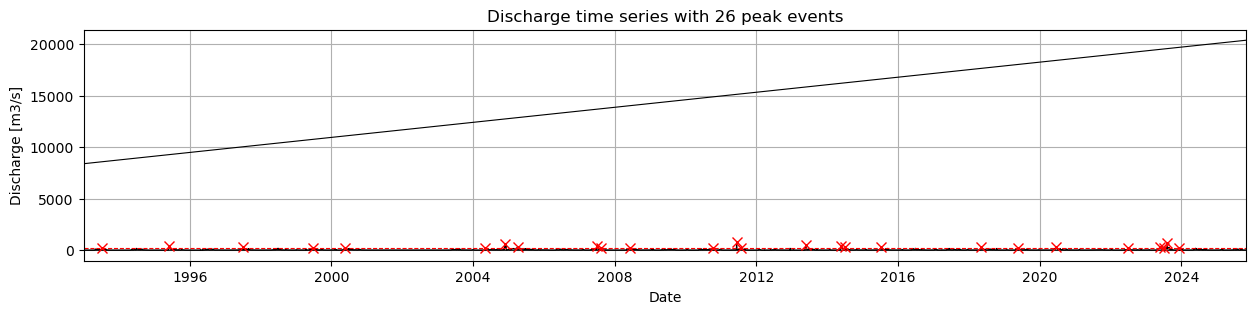

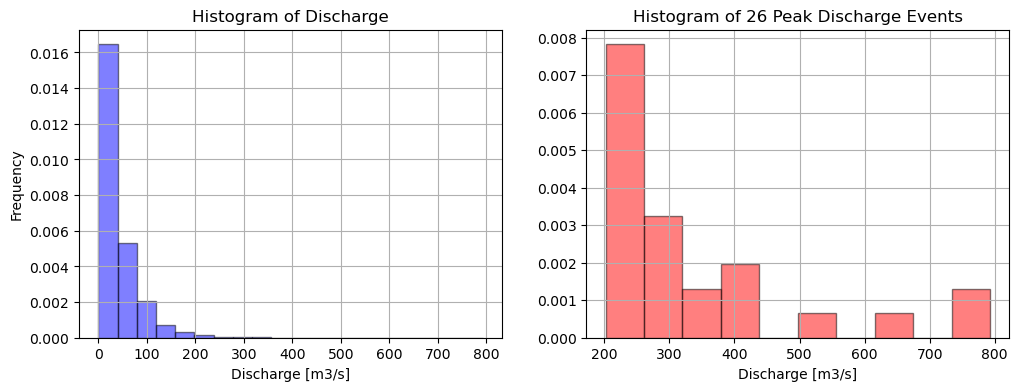

In [59]:
### discharge plottings ###
data = df.drop(columns=["Tmean [C]", "precip [mm/day]"])
data.dropna(inplace=True)
peaks, _ = find_peaks(data["Q(m3/s)"].values, height=200, distance=32)
exces = data.iloc[peaks]["Q(m3/s)"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Discharge time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge [m3/s]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])
ax.hlines(200, data.index.min(), data.index.max(), color='red', linestyle='--', label='Peak Threshold (200 m3/s)', lw=lw)
plt.savefig("..\\Figures\\discharge_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))

axes[0].hist(data["Q(m3/s)"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Discharge")
axes[0].set_xlabel("Discharge [m3/s]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].set_title(f"Histogram of {len(peaks)} Peak Discharge Events")
axes[1].set_xlabel("Discharge [m3/s]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].grid()
plt.savefig("..\\Figures\\discharge_analysis_hist.png", dpi=300)

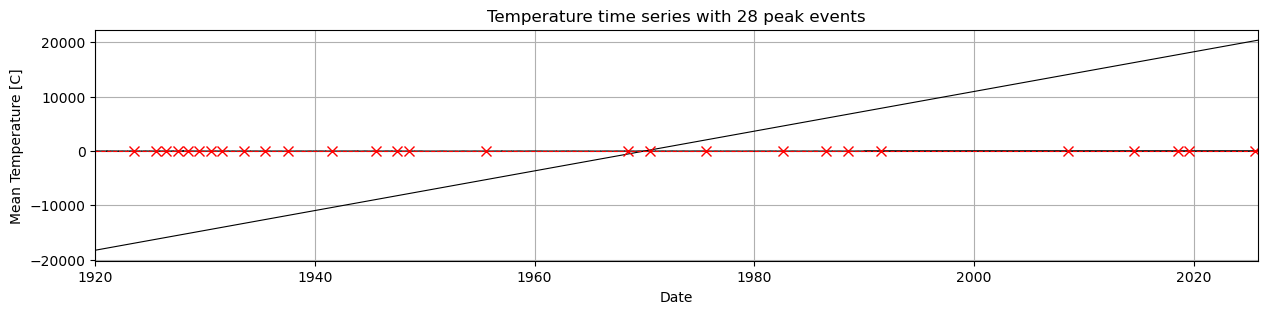

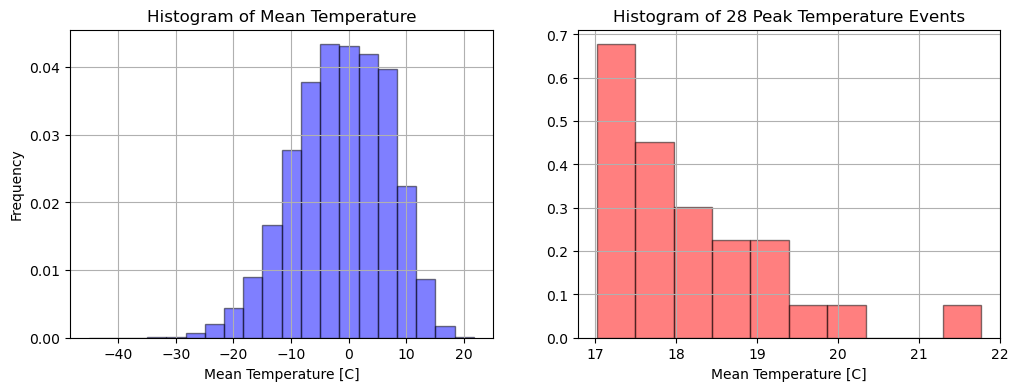

In [60]:
### temperature plottings ###
data = df.drop(columns=["precip [mm/day]", "Q(m3/s)"])
peaks, _ = find_peaks(data["Tmean [C]"].values, height=17, distance=300)
exces = data.iloc[peaks]["Tmean [C]"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Temperature time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature [C]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])
ax.hlines(17, data.index.min(), data.index.max(), color='red', linestyle='--', label='Peak Threshold (17 C)', lw=lw)
plt.savefig("..\\Figures\\temperature_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))
axes[0].hist(data["Tmean [C]"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Mean Temperature")
axes[0].set_xlabel("Mean Temperature [C]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].set_title(f"Histogram of {len(peaks)} Peak Temperature Events")
axes[1].set_xlabel("Mean Temperature [C]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].grid()
plt.savefig("..\\Figures\\temperature_analysis_hist.png", dpi=300)

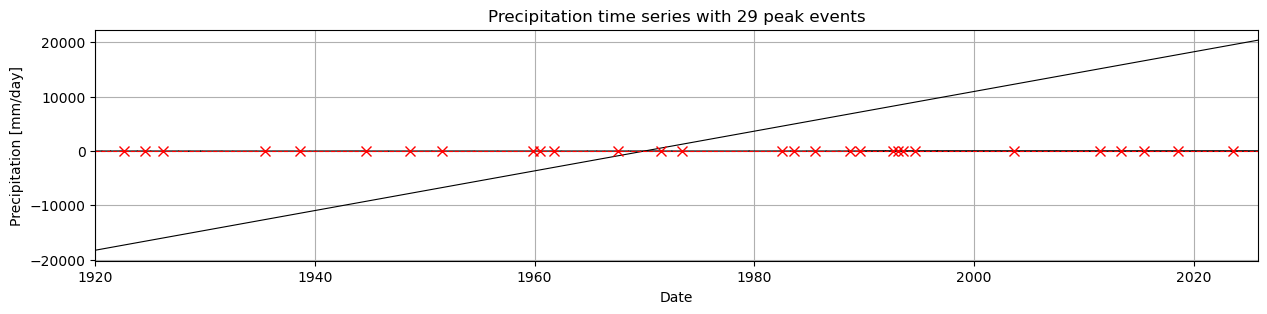

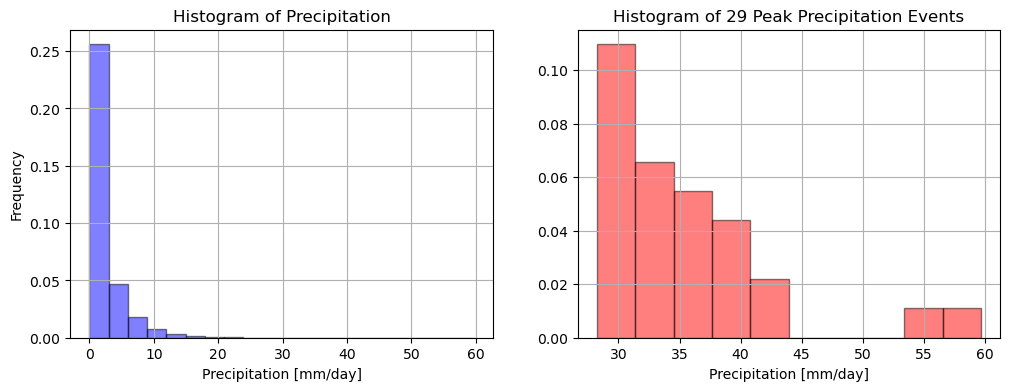

In [61]:
### precipitation plottings ###
thresh = 28

data = df.drop(columns=["Tmean [C]", "Q(m3/s)"])
peaks, _ = find_peaks(data["precip [mm/day]"].values, height=thresh, distance=100)
exces = data.iloc[peaks]["precip [mm/day]"].values
dpeak = data.index[peaks]

# timeseries with peaks
fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.plot(data.index, data.values, color=lc, linewidth=lw)
ax.plot(dpeak, exces, marker=mt, color=mc, markersize=ms, linestyle='None')
ax.set_title(f"Precipitation time series with {len(peaks)} peak events")
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation [mm/day]")
ax.grid()
ax.set_xlim([data.index.min(), data.index.max()])

ax.hlines(thresh, data.index.min(), data.index.max(), color='red', linestyle='--', label=f'Peak Threshold ({thresh} mm/day)', lw=lw)
plt.savefig("..\\Figures\\precipitation_analysis_timeseries.png", dpi=300)

# histogram of peaks
fig, axes = plt.subplots(1, 2, figsize=(w_hist, h_hist))
axes[0].hist(data["precip [mm/day]"], bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title("Histogram of Precipitation")
axes[0].set_xlabel("Precipitation [mm/day]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].set_title(f"Histogram of {len(peaks)} Peak Precipitation Events")
axes[1].set_xlabel("Precipitation [mm/day]")
axes[1].hist(exces, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[1].grid()
plt.savefig("..\\Figures\\precipitation_analysis_hist.png", dpi=300)


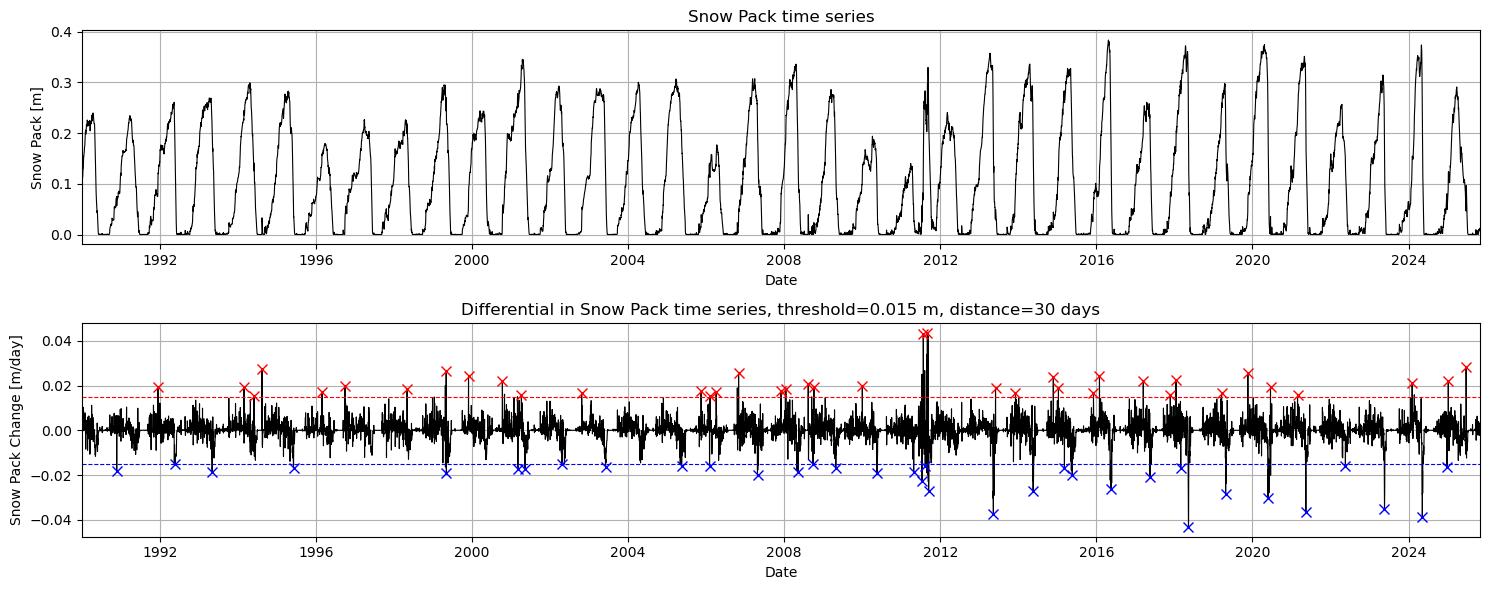

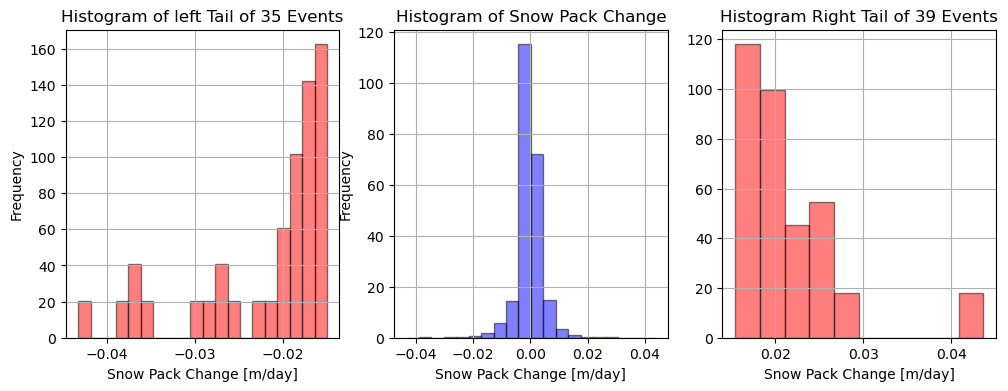

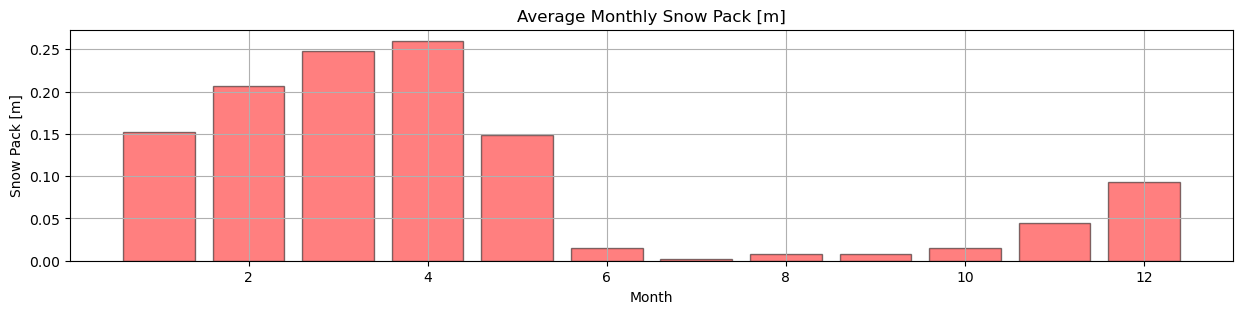

In [62]:
data = df[["Snowpack [m]"]].copy()
peaks, _ = find_peaks(data["Snowpack [m]"].values, height=0.1, distance=300)
exces = data.iloc[peaks].values
dpeak = data.index[peaks]
data.dropna(inplace=True)

data_monthly = data.groupby(data.index.month).mean()

distance_peak = 30
thresh = 0.015
diff = data["Snowpack [m]"].diff()
neg_peaks, _ = find_peaks(-diff.values, height=thresh, distance=distance_peak)
neg_exces = diff.iloc[neg_peaks].values
neg_dpeak = diff.index[neg_peaks]
peaks_snowmelt, _ = find_peaks(diff.values, height=thresh, distance=distance_peak)
exces_snowmelt = diff.iloc[peaks_snowmelt].values
dpeak_snowmelt = diff.index[peaks_snowmelt]

fig, axes = plt.subplots(2, figsize=(w_time, h_time * 2), layout='tight')
axes[0].plot(data.index, data.values, color=lc, linewidth=lw)
axes[0].set_title(f"Snow Pack time series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Snow Pack [m]")
axes[0].grid()
axes[0].set_xlim([data[data > 0].index.min(), data[data > 0].index.max()])

axes[1].plot(diff.index, diff.values, color=lc, linewidth=lw)
axes[1].plot(dpeak_snowmelt, exces_snowmelt, marker=mt, color=mc, markersize=ms, linestyle='None')
axes[1].plot(neg_dpeak, neg_exces, marker=mt, color='blue', markersize=ms, linestyle='None')
axes[1].set_title(f"Differential in Snow Pack time series, threshold={thresh} m, distance={distance_peak} days")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Snow Pack Change [m/day]")
axes[1].grid()
axes[1].set_xlim([data[data > 0].index.min(), data[data > 0].index.max()])
axes[1].hlines(thresh, data.index.min(), data.index.max(), color='red', linestyle='--', label=f'Peak Threshold ({thresh} m/day)', lw=lw)
axes[1].hlines(-thresh, data.index.min(), data.index.max(), color='blue', linestyle='--', label=f'Negative Peak Threshold (-{thresh} m/day)', lw=lw)

fig, axes = plt.subplots(1, 3, figsize=(w_hist, h_hist))
axes[0].hist(neg_exces, bins=20, color='red', edgecolor='black', alpha=alpha, density=True)
axes[0].set_title(f"Histogram of left Tail of {len(neg_exces)} Events")
axes[0].set_xlabel("Snow Pack Change [m/day]")
axes[0].set_ylabel("Frequency")
axes[0].grid()

axes[1].hist(diff, bins=20, color='blue', edgecolor='black', alpha=alpha, density=True)
axes[1].set_title("Histogram of Snow Pack Change")
axes[1].set_xlabel("Snow Pack Change [m/day]")
axes[1].set_ylabel("Frequency")
axes[1].grid()

axes[2].set_title(f"Histogram Right Tail of {len(peaks_snowmelt)} Events")
axes[2].set_xlabel("Snow Pack Change [m/day]")
axes[2].hist(exces_snowmelt, bins=10, color='red', edgecolor='black', alpha=alpha, density=True)
axes[2].grid()

fig, ax = plt.subplots(figsize=(w_time, h_time))
ax.bar(data_monthly.index, data_monthly["Snowpack [m]"].values, color='red', alpha=alpha, edgecolor='black')
ax.grid()
ax.set_title("Average Monthly Snow Pack [m]")
ax.set_xlabel("Month")
ax.set_ylabel("Snow Pack [m]")
plt.savefig("..\\Figures\\snowpack_analysis_monthly.png", dpi=300)


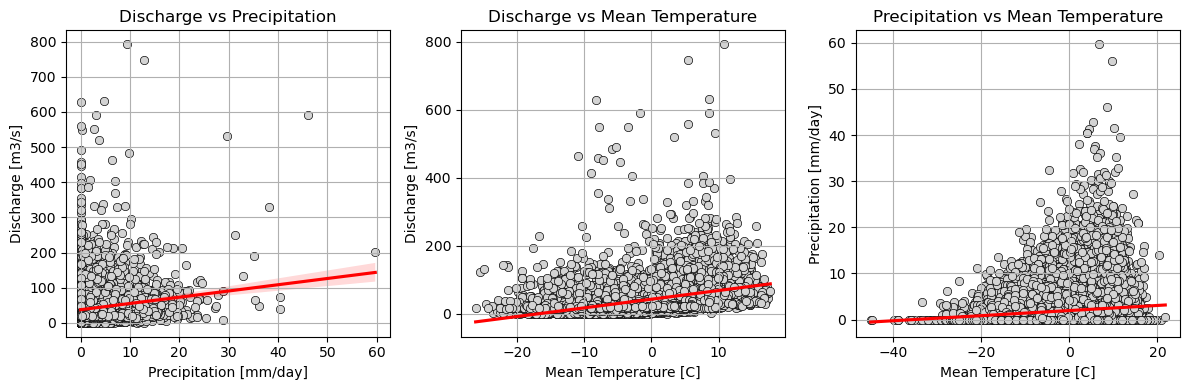

In [63]:
### correlation ###
fig, axes = plt.subplots(1,3, figsize=(w_hist, h_hist), layout='tight')
sns.scatterplot(data=df, x="precip [mm/day]", y="Q(m3/s)", ax=axes[0], color='lightgrey', edgecolor='black')
sns.regplot(data=df, x="precip [mm/day]", y="Q(m3/s)", scatter=False, color='red', ax=axes[0], label= 'regression line')
axes[0].set_title("Discharge vs Precipitation")
axes[0].set_xlabel("Precipitation [mm/day]")
axes[0].set_ylabel("Discharge [m3/s]")
axes[0].grid()

sns.scatterplot(data=df, x="Tmean [C]", y="Q(m3/s)", ax=axes[1], color='lightgrey', edgecolor='black')
sns.regplot(data=df, x="Tmean [C]", y="Q(m3/s)", scatter=False, color='red', ax=axes[1], label= 'regression line')
axes[1].set_title("Discharge vs Mean Temperature")
axes[1].set_xlabel("Mean Temperature [C]")
axes[1].set_ylabel("Discharge [m3/s]")
axes[1].grid()

sns.scatterplot(data=df, x="Tmean [C]", y="precip [mm/day]", ax=axes[2], color='lightgrey', edgecolor='black')
sns.regplot(data=df, x="Tmean [C]", y="precip [mm/day]", scatter=False, color='red', ax=axes[2], label= 'regression line')
axes[2].set_title("Precipitation vs Mean Temperature")
axes[2].set_xlabel("Mean Temperature [C]") 
axes[2].set_ylabel("Precipitation [mm/day]")
axes[2].grid()

plt.savefig("..\\Figures\\correlation_analysis.png", dpi=300)





In [64]:
# rho = []

# for i in range(60):
#     df_shift = df.dropna().copy()
#     df_shift.loc[:,"Q_shifted"] = df_shift["Q(m3/s)"].shift(i)
#     # display(df_shift)
#     df_shift = df_shift.dropna()
#     pr = stats.pearsonr(df_shift["precip [mm/day]"], df_shift["Q_shifted"])
#     rho.append(pr[0])
#     print(pr)


# print(f"maximum slope for lag = {np.argmax(rho)} days: {np.max(rho)}")
# df_shift = df.dropna().copy()
# df_shift["Q_shifted"] = df_shift["Q(m3/s)"].shift(np.argmax(rho))
# sns.scatterplot(data=df_shift, x="precip [mm/day]", y="Q_shifted", color='lightgrey', edgecolor='black')
# sns.regplot(data=df_shift, x="precip [mm/day]", y="Q_shifted", scatter=False, color='red', label= 'regression line')





In [65]:

from py_banshee.rankcorr import bn_rankcorr
from py_banshee.bn_plot import bn_visualize
from py_banshee.d_cal import test_distance
from py_banshee.copula_test import cvm_statistic
from py_banshee.prediction import inference,conditional_margins_hist

In [66]:
# df_temp = pd.read_csv("..\\Data\\Tmean_obs.csv", parse_dates=True, skiprows = 26, delimiter="\\s+", header=None) 
# df_temp.columns = ["date", "Tmean [C]",]
# df_temp["date"] = pd.to_datetime(df_temp["date"], format="%Y%m%d")
# df_temp.set_index("date", inplace=True)

# df_prcp = pd.read_csv("..\\Data\\prcp_obs.csv", parse_dates=True, skiprows = 27, delimiter="\\s+", header=None)
# df_prcp.columns = ["date", "precip [mm/day]"]
# df_prcp["date"] = pd.to_datetime(df_prcp["date"], format="%Y%m%d")
# df_prcp.set_index("date", inplace=True)

# df_disc = pd.read_csv("..\\Data\\2.595.0-Vannføring-inst-v1.csv", parse_dates=True, skiprows = 1, delimiter=";", decimal=",")
# df_disc.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
# df_disc.dropna(inplace=True)
# df_disc.columns = ["date", "Q(m3/s)"]
# df_disc.set_index(pd.to_datetime(pd.to_datetime(df_disc["date"]).dt.date), inplace=True)
# df_disc.drop(columns=["date"], inplace=True)
# df_disc = df_disc.resample("D").mean()

# df_snow = pd.read_csv("..\\Data\\snowcover.csv", parse_dates=True, skiprows = 48, delimiter="\\s+", header=None)
# df_snow.columns = ["date", "snow cover fraction"]
# df_snow["date"] = pd.to_datetime(df_snow["date"], format="%Y%m%d")
# df_snow.set_index("date", inplace=True)


# df = df_temp.join(df_prcp).join(df_disc).join(df_snow)
# df.dropna(inplace=True)
display(df)

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s),date
date,,,,,
1920-01-01,-11.853330,1.414465,NaN,NaN,1920-01-01
1920-01-02,-13.153330,0.208641,NaN,NaN,1920-01-02
1920-01-03,-20.386670,0.000000,NaN,NaN,1920-01-03
1920-01-04,-8.796666,0.000000,NaN,NaN,1920-01-04
1920-01-05,-12.690000,0.000000,NaN,NaN,1920-01-05
...,...,...,...,...,...
2025-10-27,-1.356667,0.000000,0.009877,23.653758,2025-10-27
2025-10-28,-4.233333,0.000000,0.011440,22.214355,2025-10-28
2025-10-29,-6.763333,0.852455,0.012004,20.837645,2025-10-29


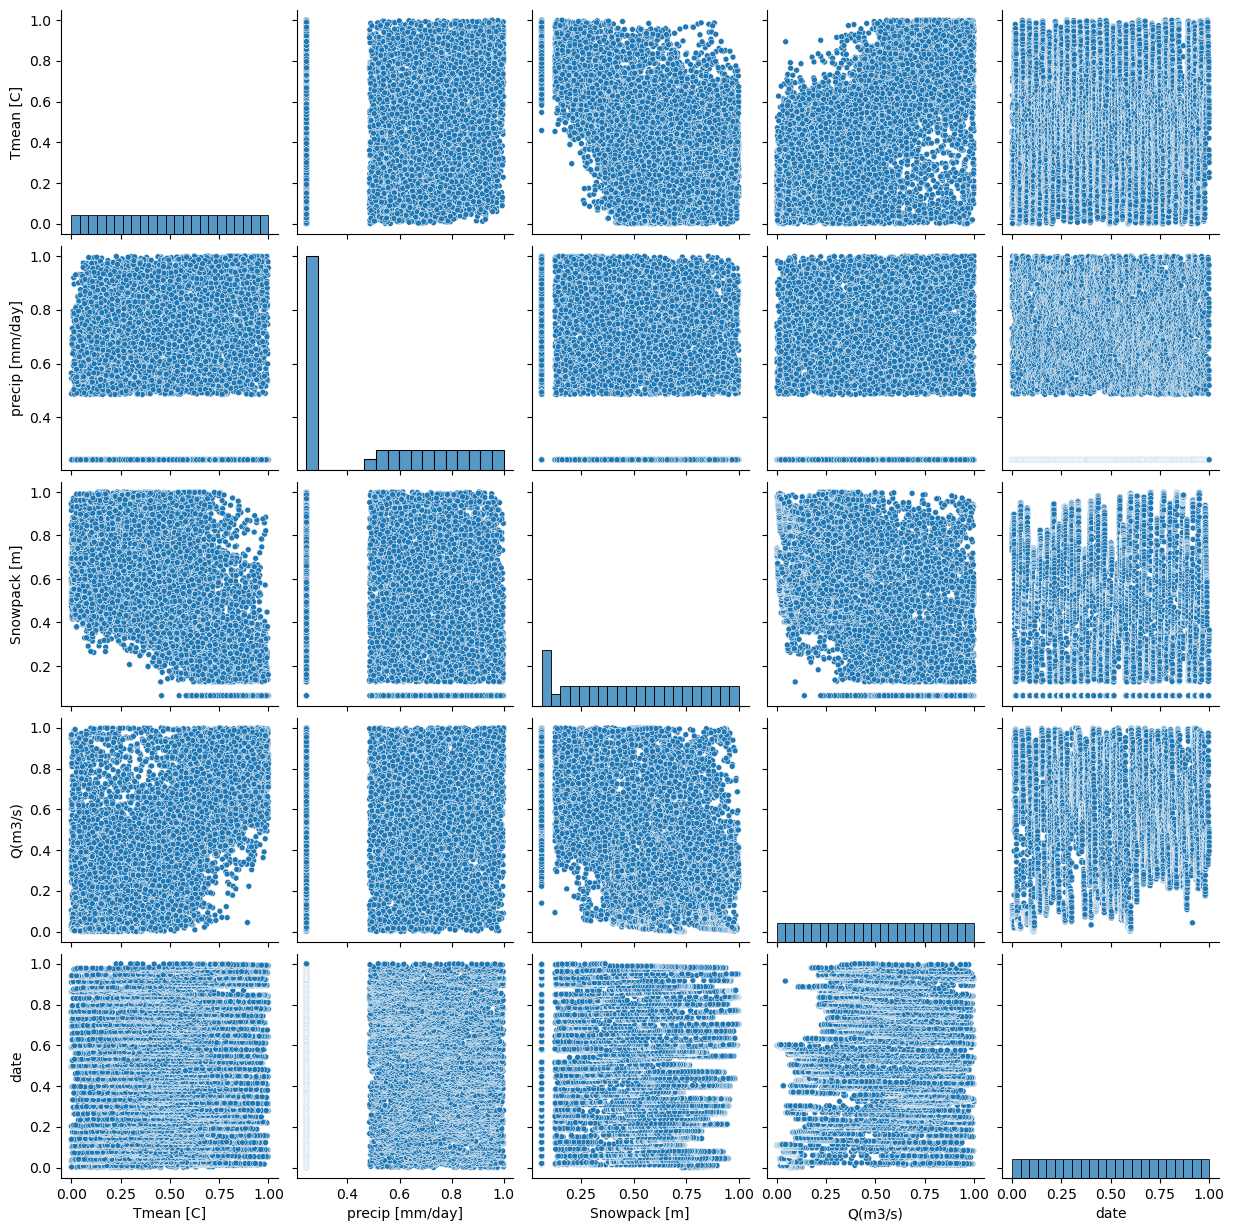

In [67]:
def unity(data):
    u_hat = data.copy()
    n = len(data)
    for col in data.columns:
        u_hat[col]= stats.rankdata(data[col]) / (n + 1)
    return u_hat
unity_df = unity(df.dropna())
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

In [68]:
unity_df.describe()

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s),date
count,10850.000000,10850.000000,10850.000000,10850.000000,10850.000000
mean,0.500000,0.500000,0.500000,0.500000,0.500000
std,0.288662,0.271720,0.288373,0.288662,0.288662
min,0.000092,0.242420,0.063036,0.000138,0.000092
25%,0.249954,0.242420,0.250046,0.250046,0.250046
50%,0.499954,0.500000,0.500000,0.500000,0.500000
75%,0.749977,0.749954,0.749954,0.749954,0.749954
max,0.999908,0.999908,0.999908,0.999908,0.999908


Precip and Snowpack both have many repeated values, which are probably zero, they are assigned the same rank.
after scaling to [0,1], this produces many points with the same u-value, which appear as horizontal or verical lines. 
The vertical stripes indicate many tied observations in the original variables, (zero precipitation)
Dependence the copula is meant to model. 

KeyboardInterrupt: 

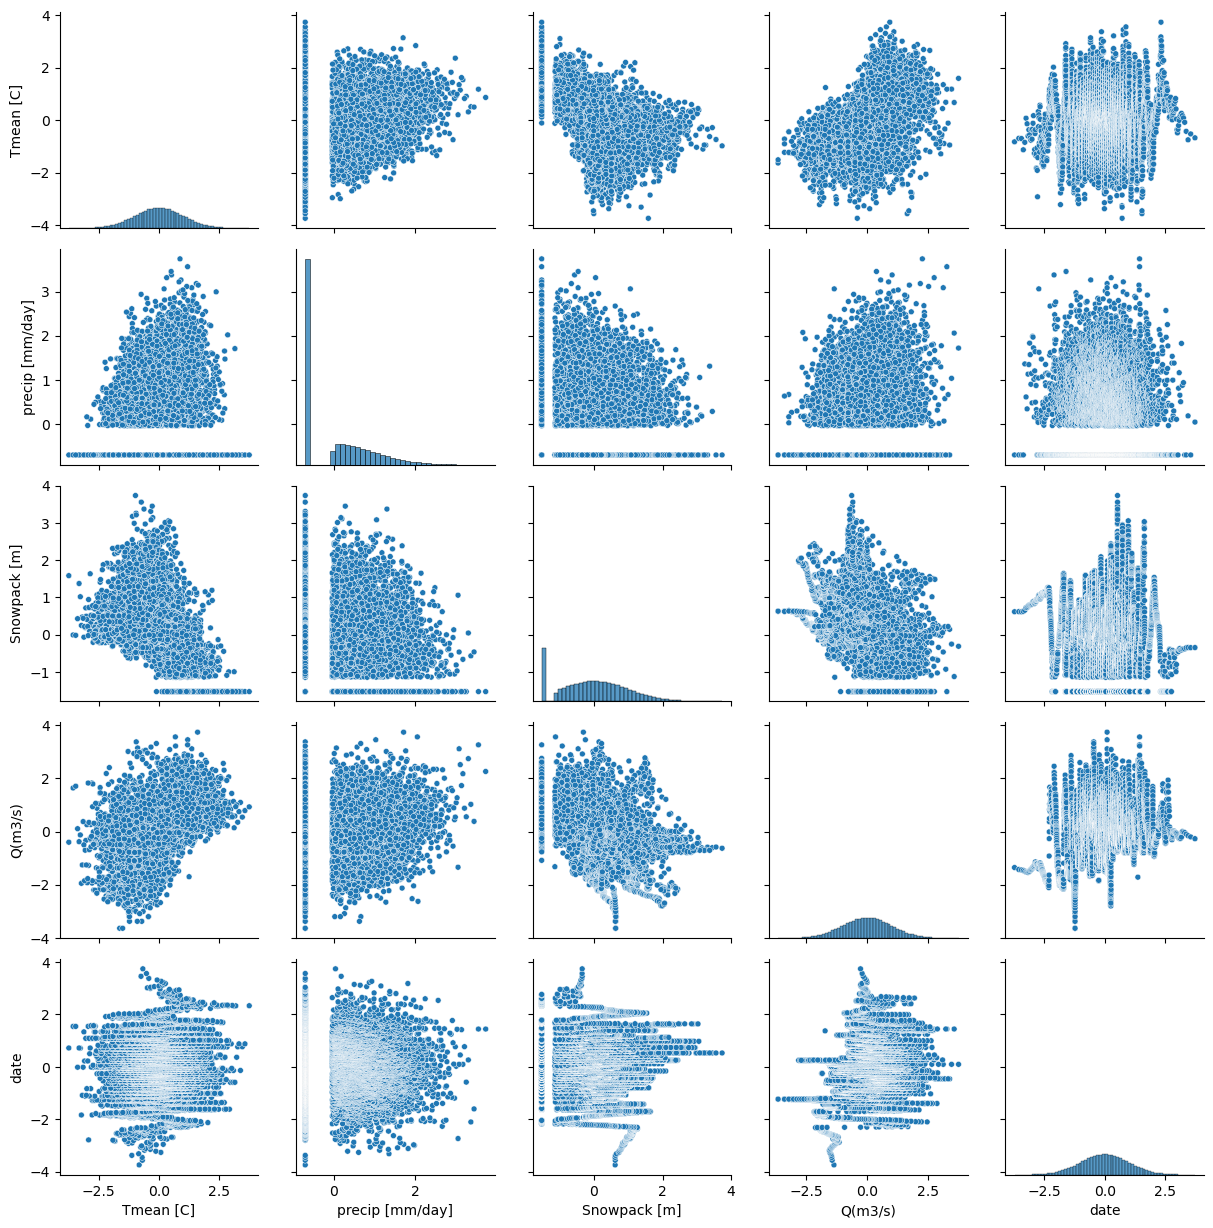

In [69]:
def sd_normal(data):
    sd_data = data.copy()
    for col in data.columns:
        sd_data[col] = stats.norm.ppf(data[col]) #inverse of the cdf, use cdf of standard normal distribution
    return sd_data

sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvinecopulib as pv
import seaborn as sns
from scipy import stats
from py_banshee.copula_test import cvm_statistic
from scipy.interpolate import interp1d


In [ ]:
print(df.columns)

Index(['Tmean [C]', 'precip [mm/day]', 'Snowpack [m]', 'Q(m3/s)', 'date'], dtype='object')


In [70]:
#import warnings  
#warnings.filterwarnings("ignore")

#M = cvm_statistic(DATA = df, names = data.columns, fig_name='cvm')#your code here. Use Banshee!
#print(M)

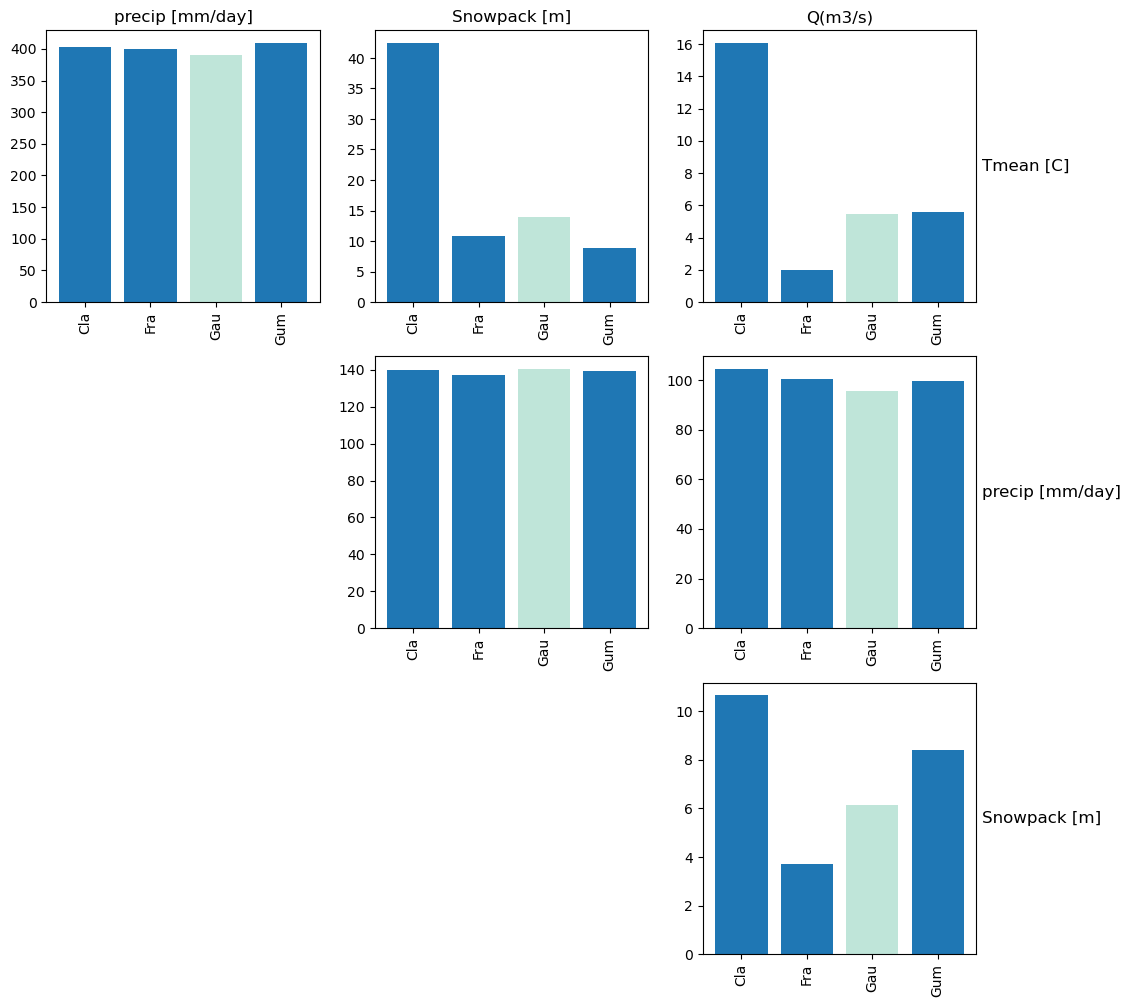

In [ ]:
#import warnings  
#warnings.filterwarnings("ignore")

#M = cvm_statistic(DATA = df, plot = 1, names = df.columns, fig_name='cvm')
#plt.show()

In [71]:
data = df.drop(columns=["Tmean [C]", "precip [mm/day]"])
data.dropna(inplace=True)
peaks, _ = find_peaks(data["Q(m3/s)"].values, height=200, distance=32)
exces = data.iloc[peaks]["Q(m3/s)"].values
dpeak = data.index[peaks]

df_max_Q = pd.DataFrame()

df_max_Q['exces'] = exces
df_max_Q['date'] = dpeak


In [72]:
print(df.columns)

Index(['Tmean [C]', 'precip [mm/day]', 'Snowpack [m]', 'Q(m3/s)', 'date'], dtype='object')


In [73]:
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month

idx_max = (
    df.groupby(['Year'])['Q(m3/s)']
      .idxmax()
      .dropna()
)

max_list = df.loc[idx_max]
display(max_list)

,Tmean [C],precip [mm/day],Snowpack [m],Q(m3/s),date,Year,Month
date,,,,,,,
1993-07-13,6.416667,6.705699,0.003152,239.157100,1993-07-13,1993,7
1994-06-30,4.653334,0.000000,0.001034,185.712500,1994-06-30,1994,6
1995-06-02,5.503334,0.000000,0.091657,383.985200,1995-06-02,1995,6
1996-08-28,7.763333,0.000000,0.000000,113.080000,1996-08-28,1996,8
1997-07-03,11.020000,0.000000,0.000000,265.306300,1997-07-03,1997,7
1998-06-29,6.503333,4.156644,0.000000,199.251500,1998-06-29,1998,6
1999-06-29,7.466666,2.584340,0.000000,248.661300,1999-06-29,1999,6
2000-05-18,3.223333,1.909716,0.050608,202.076233,2000-05-18,2000,5
2003-08-16,7.893333,1.510912,0.000444,150.487863,2003-08-16,2003,8


In [74]:
data_snow = pd.DataFrame()
data_snow = df[["Snowpack [m]"]].copy()


data_snow = data_snow[data_snow["Snowpack [m]"] > 0]
data_snow = data_snow.dropna()

data_snow['date'] = data_snow.index
display(data_snow)

,Snowpack [m],date
date,,
1990-01-01,0.107858,1990-01-01
1990-01-02,0.108081,1990-01-02
1990-01-03,0.108451,1990-01-03
1990-01-04,0.109092,1990-01-04
1990-01-05,0.108881,1990-01-05
...,...,...
2025-10-27,0.009877,2025-10-27
2025-10-28,0.011440,2025-10-28
2025-10-29,0.012004,2025-10-29


In [75]:
data_snow['Year'] = data_snow['date'].dt.year
data_snow['Month'] = data_snow['date'].dt.month

monthly_sum_snow = data_snow.groupby(['Year', 'Month'])['Snowpack [m]'].sum()
print(monthly_sum_snow)

Year  Month
1990  1        4.430062
      2        5.936291
      3        6.745495
      4        6.842484
      5        2.818415
                 ...   
2025  6        2.566558
      7        0.161844
      8        0.008089
      9        0.033395
      10       0.174857
Name: Snowpack [m], Length: 424, dtype: float64


In [76]:
winter_snowpack1990 = monthly_sum_snow.loc[1990][0:3]

In [77]:
print(winter_snowpack1990)

Month
1    4.430062
2    5.936291
3    6.745495
Name: Snowpack [m], dtype: float64


In [78]:
winter_snowpack = {}
for year in range(1993, 2026):
    winter_snowpack[year] = np.sum(monthly_sum_snow.loc[year][0:3]) + np.sum(monthly_sum_snow.loc[year-1][10:11])
    print(f"Winter snowpack for year {year}:")
    print(winter_snowpack[year])
for y in [2001, 2002]:
    winter_snowpack.pop(y, None)

Winter snowpack for year 1993:
23.054332270916667
Winter snowpack for year 1994:
19.601714726291664
Winter snowpack for year 1995:
21.75705449608333
Winter snowpack for year 1996:
13.28786534475
Winter snowpack for year 1997:
16.65356455025
Winter snowpack for year 1998:
15.404653980458331
Winter snowpack for year 1999:
18.478247983833334
Winter snowpack for year 2000:
20.13566405925
Winter snowpack for year 2001:
25.977050411708333
Winter snowpack for year 2002:
21.588894449166666
Winter snowpack for year 2003:
22.54642431625
Winter snowpack for year 2004:
24.49205323616667
Winter snowpack for year 2005:
24.750967735775
Winter snowpack for year 2006:
11.373079495462498
Winter snowpack for year 2007:
25.804884260916666
Winter snowpack for year 2008:
24.16589381345
Winter snowpack for year 2009:
20.81288094625
Winter snowpack for year 2010:
14.567757802333333
Winter snowpack for year 2011:
9.355474039708334
Winter snowpack for year 2012:
18.204313249808333
Winter snowpack for year 2013:

In [79]:
display(winter_snowpack)

{1993: 23.054332270916667,
 1994: 19.601714726291664,
 1995: 21.75705449608333,
 1996: 13.28786534475,
 1997: 16.65356455025,
 1998: 15.404653980458331,
 1999: 18.478247983833334,
 2000: 20.13566405925,
 2003: 22.54642431625,
 2004: 24.49205323616667,
 2005: 24.750967735775,
 2006: 11.373079495462498,
 2007: 25.804884260916666,
 2008: 24.16589381345,
 2009: 20.81288094625,
 2010: 14.567757802333333,
 2011: 9.355474039708334,
 2012: 18.204313249808333,
 2013: 24.661790304458336,
 2014: 24.11921413954167,
 2015: 20.6239136066125,
 2016: 17.65959530259167,
 2017: 15.5364276489,
 2018: 24.730417696875,
 2019: 16.777442806208335,
 2020: 26.8014557663125,
 2021: 19.798325255712502,
 2022: 17.05326716354167,
 2023: 15.206091607212501,
 2024: 18.197290393916667,
 2025: 18.098210285683333}

In [80]:
len(winter_snowpack)

31

In [81]:
len(max_list['Q(m3/s)'])

31

Text(0.5, 1.0, 'Cumulative snowpack over winter months vs max discharge')

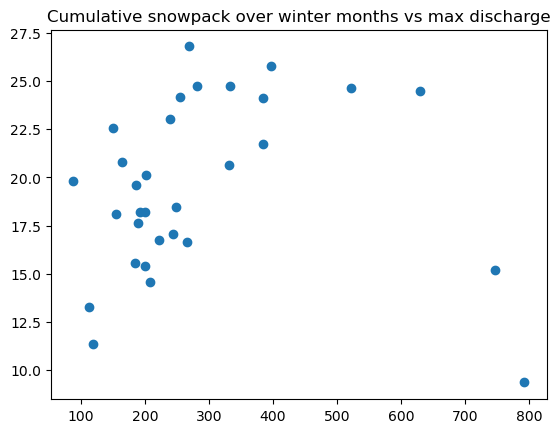

In [82]:
plt.scatter(max_list['Q(m3/s)'], winter_snowpack.values())
plt.title('Cumulative snowpack over winter months vs max discharge')



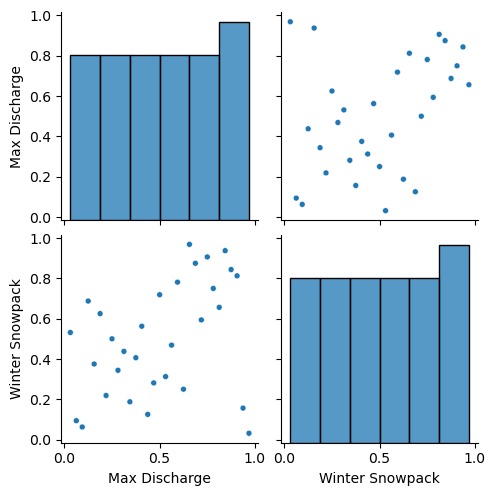

In [83]:
def unity(data):
    u_hat = data.copy()
    n = len(data)
    for col in data.columns:
        u_hat[col]= stats.rankdata(data[col]) / (n + 1)
    return u_hat
unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Winter Snowpack': list(winter_snowpack.values())}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

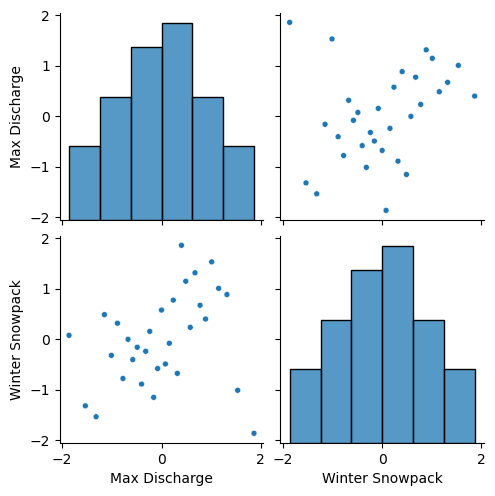

In [84]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()

In [85]:
max_list['date']

date
1993-07-13   1993-07-13
1994-06-30   1994-06-30
1995-06-02   1995-06-02
1996-08-28   1996-08-28
1997-07-03   1997-07-03
1998-06-29   1998-06-29
1999-06-29   1999-06-29
2000-05-18   2000-05-18
2003-08-16   2003-08-16
2004-11-28   2004-11-28
2005-04-10   2005-04-10
2006-06-14   2006-06-14
2007-07-06   2007-07-06
2008-06-04   2008-06-04
2009-07-21   2009-07-21
2010-10-07   2010-10-07
2011-06-11   2011-06-11
2012-12-14   2012-12-14
2013-05-23   2013-05-23
2014-05-25   2014-05-25
2015-07-07   2015-07-07
2016-06-27   2016-06-27
2017-06-11   2017-06-11
2018-05-11   2018-05-11
2019-05-23   2019-05-23
2020-06-22   2020-06-22
2021-02-15   2021-02-15
2022-06-29   2022-06-29
2023-08-09   2023-08-09
2024-05-29   2024-05-29
2025-09-15   2025-09-15
Name: date, dtype: datetime64[ns]

In [86]:
precip1993 = np.sum(df['precip [mm/day]'].loc['1993-07-06':'1993-07-13'])
print(precip1993)

precip1994 = np.sum(df['precip [mm/day]'].loc['1994-06-24':'1994-06-30'])
print(precip1994)

precip1995 = np.sum(df['precip [mm/day]'].loc['1995-05-25':'1995-06-02'])
print(precip1995)

precip1996 = np.sum(df['precip [mm/day]'].loc['1996-08-21':'1996-08-28'])
print(precip1996)

precip1997 = np.sum(df['precip [mm/day]'].loc['1997-06-26':'1997-07-03'])
print(precip1997)

precip1998 = np.sum(df['precip [mm/day]'].loc['1998-06-22':'1998-06-29'])



70.025462
29.106485999999997
58.782087000000004
58.2748063
54.2982945


In [87]:
precip = np.zeros(len(max_list))

for i, date in enumerate(max_list['date']):
    precip[i] = df.loc[date - pd.Timedelta(days=5):date, 'precip [mm/day]'].sum()

        
print(precip)


[ 68.092821    26.890005    53.186526    53.0470583   52.0867635
  23.824232    32.07016      8.17342     75.83504     27.0240754
  12.074175     0.          32.58953      0.          47.398585
  65.494845   100.881457     5.29838204  57.191805    16.141804
  42.813773    32.718293    40.686198    18.796685    34.505292
  19.65936798   3.062708    45.766521   127.83029     30.0393742
  39.058058  ]


Text(0.5, 1.0, 'precipitation (7 days to max event) vs max discharge')

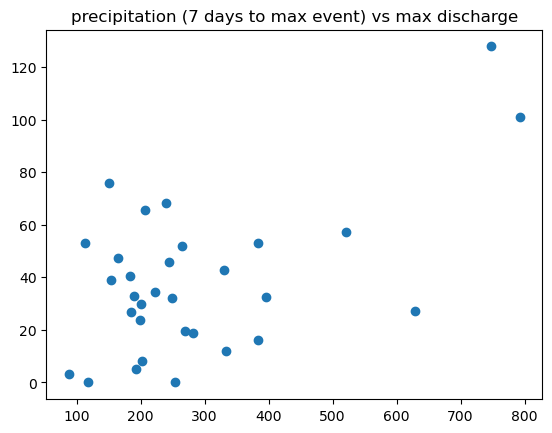

In [88]:
plt.scatter(max_list['Q(m3/s)'], precip)
plt.title('precipitation (7 days to max event) vs max discharge')

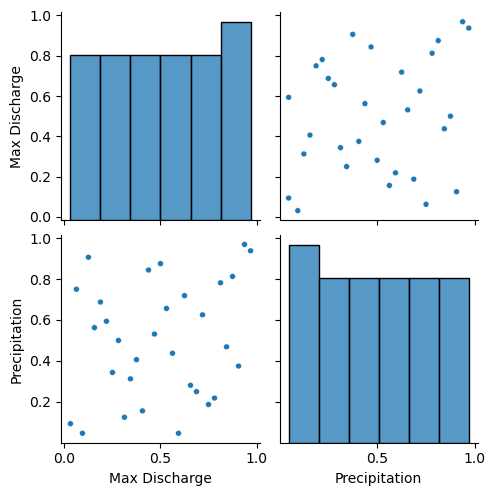

In [89]:
unity_df = unity(pd.DataFrame({'Max Discharge': max_list['Q(m3/s)'].values, 'Precipitation': precip}))
sns.pairplot(data=unity_df, height=2.5, plot_kws = dict(size=0.1))

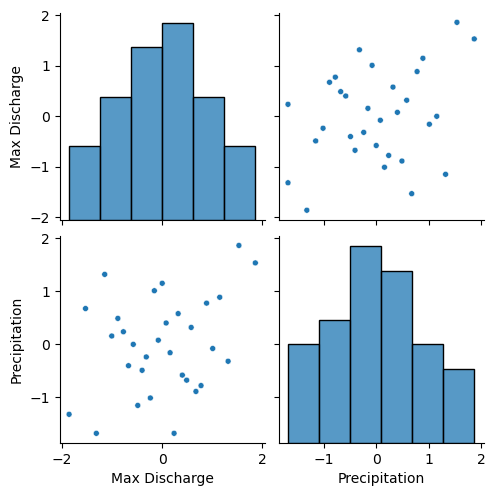

In [90]:
sd_data = sd_normal(unity_df)
sns.pairplot(sd_data, height=2.5,plot_kws=dict(size=.1))
plt.show()
